# Markov Chains - simulating distributions

## Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1

Write a code to analyze a discrete-time Markov Chain with 5 states ($S = \{0, 1, 2, 3, 4\}$) using 2 methods.

### Method 1: Stochastic Simulation

Simulate the chain for large $n$ steps by randomly picking the next state based on the transition probabilities.

**Tasks:**

* Plot a **frequency of the state occurrences**.
* Calculate the **theoretical steady-state probability** and compare the simulated result with the theoretical value.
* Determine the **final mean observable** and compare the simulated result with the theoretical value.

### Method 2: Matrix Iteration

Use the formula $P_{t+1} = P_t \times T$ or $P_{t+1} = T^T \times P_t$ where $P_t$ is the probability distribution vector at the step $t$.

* Compare the resulting distribution and mean observable with the results from Method 1.
* Why is the final distribution uniform? The transition probabilities are defined as:

$$T(s_i \to s_j) = 1/3 \text{ if } j = i \pm 1 \text{ or } j = i.$$

In [20]:
# Matrix construction

n_states = 5
T = np.zeros(shape=(n_states, n_states))
for i in range(n_states):
    for j in range(n_states):
        if j==i or abs(j-i) == 1:
            T[i, j] = 1/3

for i in [0, n_states-1]:
    T[i, i] = 1 - (np.sum(T[i, :]) - T[i, i])
print(f"Transition matrix T:\n {T}")

Transition matrix T:
 [[0.66666667 0.33333333 0.         0.         0.        ]
 [0.33333333 0.33333333 0.33333333 0.         0.        ]
 [0.         0.33333333 0.33333333 0.33333333 0.        ]
 [0.         0.         0.33333333 0.33333333 0.33333333]
 [0.         0.         0.         0.33333333 0.66666667]]


In [26]:
# Parameters
n_steps = 10000
states = np.arange(n_states)


# --- METHOD 1 ---
current_state = 0
history = [current_state]

for _ in range(n_steps):
    current_state = np.random.choice(a = states, p = T[current_state])
    history.append(current_state)

simulated_probs = np.bincount(history, minlength=n_states) / len(history)
simulated_mean = np.mean(history)

# --- METHOD 2 ---
p_t = np.array([1, 0, 0, 0, 0])  # Startujemy ze stanu 0
for _ in range(100):  # Wystarczająca liczba kroków do zbieżności
    p_t = p_t @ T

matrix_mean = np.sum(states * p_t)

[0.18068193 0.18918108 0.21017898 0.21187881 0.20807919]



Metoda 1 (Symulacja): Rozkład: [0.20067993 0.20077992 0.20037996 0.19918008 0.1989801 ], Średnia: 1.995
Metoda 2 (Macierz):   Rozkład: [0.20000044 0.20000027 0.2        0.19999973 0.19999956], Średnia: 2.000


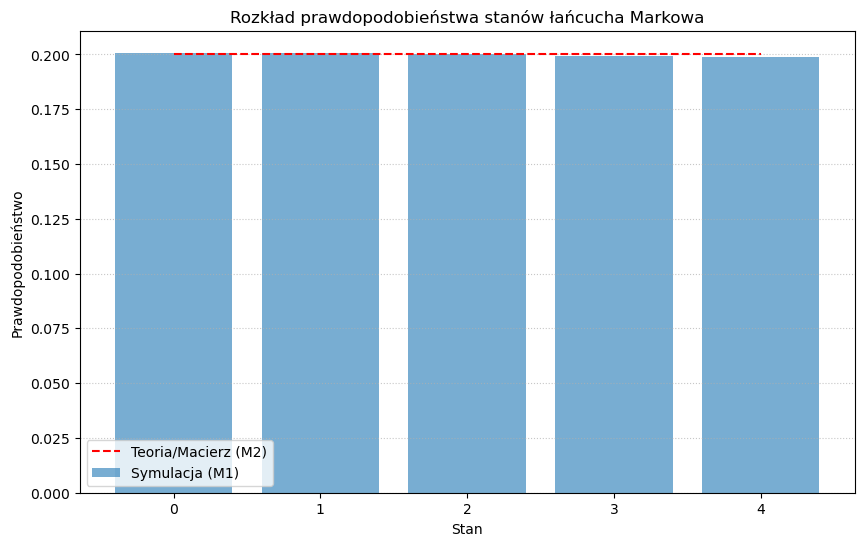

In [24]:
# --- WYNIKI I WYKRES ---
print(f"\nMetoda 1 (Symulacja): Rozkład: {simulated_probs}, Średnia: {simulated_mean:.3f}")
print(f"Metoda 2 (Macierz):   Rozkład: {p_t}, Średnia: {matrix_mean:.3f}")

plt.figure(figsize=(10, 6))
plt.bar(states, simulated_probs, alpha=0.6, label='Symulacja (M1)')
plt.step(states, p_t, where='mid', color='red', label='Teoria/Macierz (M2)', linestyle='--')
plt.title("Rozkład prawdopodobieństwa stanów łańcucha Markowa")
plt.xlabel("Stan")
plt.ylabel("Prawdopodobieństwo")
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

fig, axs = plt.subplots(1, 2, squeeze=False, figsize=(10, 4))
axs[0].bar(states, simulated_probs, alpha=0.6, label='Symulacja (M1)')



# Odpowiedź na pytanie: Dlaczego rozkład jest jednostajny?
# Ponieważ macierz T jest stochastyczna i symetryczna (podwójnie stochastyczna),
# co sprawia, że wektor jednostajny [0.2, 0.2, 0.2, 0.2, 0.2] jest jej punktem stałym.